<a href="https://colab.research.google.com/github/avindumihisara0229-code/ErgoSense/blob/Ramzan/Drowsiness_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Install necessary libraries
!pip uninstall mediapipe -y
!pip install mediapipe==0.10.14 opencv-python-headless tensorflow scikit-learn matplotlib seaborn numpy pandas tqdm

Found existing installation: mediapipe 0.10.14
Uninstalling mediapipe-0.10.14:
  Successfully uninstalled mediapipe-0.10.14
  Using cached mediapipe-0.10.14-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.7 kB)
Using cached mediapipe-0.10.14-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (35.7 MB)


In [3]:
# Import all required libraries
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mediapipe as mp
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle
from tqdm import tqdm

#TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

print(f"MediaPipe version: {mp.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print("All libraries imported successfully")

MediaPipe version: 0.10.14
TensorFlow version: 2.19.0
All libraries imported successfully


## Connect Google Drive

In [4]:
# Connect Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Define dataset paths
DATASET_PATH = '/content/drive/MyDrive/dataset_new'
TRAIN_PATH = os.path.join(DATASET_PATH, 'train')
TEST_PATH = os.path.join(DATASET_PATH, 'test')

# Verify dataset exists
if os.path.exists(DATASET_PATH):
    print("Dataset found!")
    print("\nTrain folders:", os.listdir(TRAIN_PATH))
    print("Test folders:", os.listdir(TEST_PATH))
else:
    print("ERROR: Dataset not found. Please upload dataset to Google Drive.")

Dataset found!

Train folders: ['no_yawn', 'yawn', 'Open', 'Closed']
Test folders: ['yawn', 'Closed', 'Open', 'no_yawn']


## EYE STATE DETECTION (CNN)

## Load and preprocess Eye images

In [6]:
def load_eye_images(base_path, img_size=(64, 64)):
    """Load eye images (Open/Closed) and prepare for CNN"""
    images = []
    labels = []

    # 0 = Open (Alert), 1 = Closed (Drowsy)
    eye_folders = {'Open': 0, 'Closed': 1}

    for folder_name, label in eye_folders.items():
        folder_path = os.path.join(base_path, folder_name)

        if not os.path.exists(folder_path):
            print(f"Warning: {folder_name} folder not found!")
            continue

        print(f"Loading {folder_name} images...")
        image_files = [f for f in os.listdir(folder_path) if not f.startswith('.')]

        for img_file in tqdm(image_files):
            img_path = os.path.join(folder_path, img_file)

            # Read and resize image
            img = cv2.imread(img_path)
            if img is None:
                continue

            # Convert to RGB and resize
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, img_size)

            images.append(img)
            labels.append(label)

    # Convert to numpy arrays and normalize
    images = np.array(images, dtype='float32') / 255.0
    labels = np.array(labels)

    return images, labels

# Load training and test eye images
print("Loading TRAINING eye images...")
X_train_eye, y_train_eye = load_eye_images(TRAIN_PATH)

print("\nLoading TEST eye images...")
X_test_eye, y_test_eye = load_eye_images(TEST_PATH)

print(f"\nTraining eye images: {X_train_eye.shape}")
print(f"Training eye labels: {y_train_eye.shape}")
print(f"Open (Alert): {np.sum(y_train_eye == 0)} | Closed (Drowsy): {np.sum(y_train_eye == 1)}")

print(f"\nTest eye images: {X_test_eye.shape}")
print(f"Test eye labels: {y_test_eye.shape}")
print(f"Open (Alert): {np.sum(y_test_eye == 0)} | Closed (Drowsy): {np.sum(y_test_eye == 1)}")

Loading TRAINING eye images...
Loading Open images...


100%|██████████| 617/617 [00:17<00:00, 36.07it/s]


Loading Closed images...


100%|██████████| 617/617 [00:12<00:00, 51.36it/s]



Loading TEST eye images...
Loading Open images...


100%|██████████| 109/109 [00:01<00:00, 57.51it/s] 


Loading Closed images...


100%|██████████| 109/109 [00:02<00:00, 51.63it/s]


Training eye images: (1234, 64, 64, 3)
Training eye labels: (1234,)
Open (Alert): 617 | Closed (Drowsy): 617

Test eye images: (218, 64, 64, 3)
Test eye labels: (218,)
Open (Alert): 109 | Closed (Drowsy): 109


## Build CNN Model for Eye Classification

In [8]:
# Build CNN model
eye_model = Sequential([
    # Input layer
    keras.Input(shape=(64, 64, 3)),

    # First convolutional block
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Second convolutional block
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Third convolutional block
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Flatten and dense layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification: Open(0) or Closed(1)
])

# Compile model
eye_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Eye Classification CNN Model:")
eye_model.summary()

Eye Classification CNN Model:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

## Train Eye Classification Model

In [9]:
# Train the model
print("Training Eye Classification Model...")

history = eye_model.fit(
    X_train_eye, y_train_eye,
    validation_data=(X_test_eye, y_test_eye),
    epochs=20,
    batch_size=32,
    verbose=1
)

print("\nTraining completed!")

Training Eye Classification Model...
Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 251ms/step - accuracy: 0.7057 - loss: 0.5517 - val_accuracy: 0.9495 - val_loss: 0.1429
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 268ms/step - accuracy: 0.9181 - loss: 0.2250 - val_accuracy: 0.9541 - val_loss: 0.1131
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 214ms/step - accuracy: 0.9594 - loss: 0.0901 - val_accuracy: 0.9633 - val_loss: 0.1160
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 223ms/step - accuracy: 0.9743 - loss: 0.0692 - val_accuracy: 0.9633 - val_loss: 0.1039
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 263ms/step - accuracy: 0.9800 - loss: 0.0631 - val_accuracy: 0.9633 - val_loss: 0.0940
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 18s 208ms/step - accuracy: 0.9919 - loss: 0.0312 - val_accuracy: 0.9633 - val_loss: 0.1057
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 210ms/step - accuracy: 0.9775 - loss: 0.0723 - val_accuracy: 0.9633 - val_loss: 0.0786
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 257ms/step - accura

## Initialize MediaPipe Face Mesh

In [18]:
# Initialize MediaPipe Face Mesh using direct import
from mediapipe.python.solutions import face_mesh

face_mesh_detector = face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.3
)

# Define landmark indices for eyes and mouth
# Left eye landmarks
LEFT_EYE = [362, 385, 387, 263, 373, 380]
# Right eye landmarks
RIGHT_EYE = [33, 160, 158, 133, 153, 144]
# Mouth landmarks
MOUTH = [61, 146, 91, 181, 84, 17, 314, 405, 321, 375, 291, 308, 324, 318, 402, 317, 14, 87, 178, 88]

print("MediaPipe Face Mesh initialized successfully")

MediaPipe Face Mesh initialized successfully


## Define EAR and MAR calculation function

In [19]:
def calculate_distance(point1, point2):
    """Calculate Euclidean distance between two points"""
    return np.sqrt((point1[0] - point2[0])**2 + (point1[1] - point2[1])**2)

def calculate_ear(eye_landmarks):
    """Calculate Eye Aspect Ratio (EAR)"""
    # Vertical distances
    vertical1 = calculate_distance(eye_landmarks[1], eye_landmarks[5])
    vertical2 = calculate_distance(eye_landmarks[2], eye_landmarks[4])

    # Horizontal distance
    horizontal = calculate_distance(eye_landmarks[0], eye_landmarks[3])

    # EAR formula
    if horizontal == 0:
        return 0
    ear = (vertical1 + vertical2) / (2.0 * horizontal)
    return ear

def calculate_mar(mouth_landmarks):
    """Calculate Mouth Aspect Ratio (MAR)"""
    # Vertical distances
    vertical1 = calculate_distance(mouth_landmarks[2], mouth_landmarks[10])
    vertical2 = calculate_distance(mouth_landmarks[4], mouth_landmarks[8])
    vertical3 = calculate_distance(mouth_landmarks[6], mouth_landmarks[14])

    # Horizontal distance
    horizontal = calculate_distance(mouth_landmarks[0], mouth_landmarks[12])

    # MAR formula
    if horizontal == 0:
        return 0
    mar = (vertical1 + vertical2 + vertical3) / (3.0 * horizontal)
    return mar

print("Feature calculation functions defined successfully")

Feature calculation functions defined successfully


## Define feature extraction function

In [20]:
def extract_features_from_image(image_path):
    """Extract EAR and MAR features from a single image"""
    try:
        # Read image
        image = cv2.imread(image_path)
        if image is None:
            return None

        # Convert to RGB
        rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Process with MediaPipe
        results = face_mesh.process(rgb_image)

        if not results.multi_face_landmarks:
            return None

        # Get landmarks
        landmarks = results.multi_face_landmarks[0].landmark
        h, w = image.shape[:2]

        # Extract eye landmarks
        left_eye_points = [(landmarks[i].x * w, landmarks[i].y * h) for i in LEFT_EYE]
        right_eye_points = [(landmarks[i].x * w, landmarks[i].y * h) for i in RIGHT_EYE]

        # Extract mouth landmarks
        mouth_points = [(landmarks[i].x * w, landmarks[i].y * h) for i in MOUTH]

        # Calculate ratios
        left_ear = calculate_ear(left_eye_points)
        right_ear = calculate_ear(right_eye_points)
        avg_ear = (left_ear + right_ear) / 2.0

        mar = calculate_mar(mouth_points)

        return [avg_ear, mar]

    except Exception as e:
        return None


print("Feature extraction function defiend successsfully")

Feature extraction function defiend successsfully


In [21]:
def load_dataset(base_path):
    """Load and extract features from all images in dataset"""
    features = []
    labels = []

    #Define lable mapping based on folder structure
    #Binary lables: 0 Alert (Open eyes , no yawn), 1=Drowsy (Closed eyes or yawning )
    label_map = {
        'Open': 0, #Alert-eye open
        'no_yawn': 0, #Alert-not yawning
        'Closed': 1, #Drowsy-eyes closed
        'yawn': 1 #Drowsy-yawning
    }

    folders = os.listdir(base_path)

    for folder in folders:
        # Skip hidden files and non-mapped folders
        if folder.startswith('.') or folder not in label_map:
            continue

        folder_path = os.path.join(base_path, folder)
        if not os.path.isdir(folder_path):
            continue

        print(f"Processing {folder} folder...")
        images = os.listdir(folder_path)

        for img_name in tqdm(images):
            # Skip hidden files
            if img_name.startswith('.'):
                continue

            img_path = os.path.join(folder_path, img_name)

            # Extract features
            feature_vector = extract_features_from_image(img_path)

            if feature_vector is not None:
                features.append(feature_vector)
                labels.append(label_map[folder])

    return np.array(features), np.array(labels)

print("loading function created successfully")

loading function created successfully


Testing: /content/drive/MyDrive/dataset_new/train/Open/_138.jpg
File exists: True
Image loaded! Shape: (300, 387, 3)


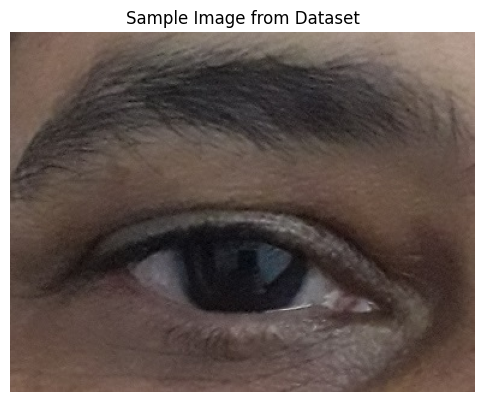


Face detected: False
NO FACE DETECTED - This is the problem!


In [24]:
# DEBUG: Check one sample image
import matplotlib.pyplot as plt

test_img_path = os.path.join(TRAIN_PATH, 'Open')
test_images = [f for f in os.listdir(test_img_path) if not f.startswith('.')]

if test_images:
    sample_img = os.path.join(test_img_path, test_images[0])
    print(f"Testing: {sample_img}")
    print(f"File exists: {os.path.exists(sample_img)}")

    # Try to read image
    img = cv2.imread(sample_img)
    if img is not None:
        print(f"Image loaded! Shape: {img.shape}")

        # Display image
        plt.figure(figsize=(6, 6))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title("Sample Image from Dataset")
        plt.axis('off')
        plt.show()

        # Try feature extraction with detailed output
        rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        results = face_mesh_detector.process(rgb_img)

        print(f"\nFace detected: {results.multi_face_landmarks is not None}")
        if results.multi_face_landmarks:
            print(f"Number of faces: {len(results.multi_face_landmarks)}")
        else:
            print("NO FACE DETECTED - This is the problem!")
    else:
        print("ERROR: Cannot read image file!")
else:
    print("No images found in folder!")

## Extract Features from Dataset

In [22]:
# Extract features from training data
print("Extracting features from TRAINING data...")
X_train, y_train = load_dataset(TRAIN_PATH)
print(f"\nTraining data shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Alert samples: {np.sum(y_train == 0)}")
print(f"Drowsy samples: {np.sum(y_train == 1)}")

Extracting features from TRAINING data...
Processing no_yawn folder...


100%|██████████| 616/616 [00:04<00:00, 139.23it/s]


Processing yawn folder...


100%|██████████| 617/617 [00:04<00:00, 124.60it/s]


Processing Open folder...


100%|██████████| 617/617 [00:03<00:00, 190.04it/s]


Processing Closed folder...


100%|██████████| 617/617 [00:03<00:00, 180.19it/s]


Training data shape: (0,)
Training labels shape: (0,)
Alert samples: 0
Drowsy samples: 0


In [23]:
# Extract features from test data
print("Extracting features from TEST data...")
X_test, y_test = load_dataset(TEST_PATH)
print(f"\nTest data shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")
print(f"Alert samples: {np.sum(y_test == 0)}")
print(f"Drowsy samples: {np.sum(y_test == 1)}")

Extracting features from TEST data...
Processing yawn folder...


100%|██████████| 106/106 [00:00<00:00, 117.82it/s]


Processing Closed folder...


100%|██████████| 109/109 [00:00<00:00, 180.18it/s]


Processing Open folder...


100%|██████████| 109/109 [00:00<00:00, 197.51it/s]


Processing no_yawn folder...


100%|██████████| 109/109 [00:00<00:00, 144.94it/s]


Test data shape: (0,)
Test labels shape: (0,)
Alert samples: 0
Drowsy samples: 0


## Data Visualization and Analysis

In [16]:
# Check if data extraction was successful
if len(X_train) == 0:
    print("ERROR: No features extracted! Check your dataset and images.")
    print("Possible reasons:")
    print("1. No faces detected in images")
    print("2. Images are corrupted or wrong format")
    print("3. Dataset path is incorrect")
else:
    # Create a DataFrame for easier analysis
    df_train = pd.DataFrame(X_train, columns=['EAR', 'MAR'])
    df_train['Label'] = y_train
    df_train['State'] = df_train['Label'].map({0: 'Alert', 1: 'Drowsy'})

    print("Training Data Statistics:")
    print(df_train.groupby('State').describe())

ERROR: No features extracted! Check your dataset and images.
Possible reasons:
1. No faces detected in images
2. Images are corrupted or wrong format
3. Dataset path is incorrect
